In [29]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

plt.style.use('ggplot')

print("Libraries imported successfully.")

Libraries imported successfully.


In [30]:
# ==========================================================
# Load Processed Dataset
# ==========================================================

orders = pd.read_csv("datasets/processed_orders.csv")

print("Processed dataset loaded successfully.")

Processed dataset loaded successfully.


In [31]:
print("="*60)
print("Dataset Shape")
print("="*60)

print(f"Rows    : {orders.shape[0]}")
print(f"Columns : {orders.shape[1]}")

Dataset Shape
Rows    : 5000
Columns : 34


In [54]:
orders.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Factory,Factory Latitude,Factory Longitude,Distance (km),Lead Time,Profit Margin (%),Sales per Unit,Cost per Unit,Distance Category,High Value Order,Route ID,Shipping Rate ($/km),Estimated Shipping Cost,Delivery Efficiency Score,Factory Order Count,Factory Workload
0,1,ORD00001,2025-02-07,2025-02-08,1,CUST9313,USA,Houston,TX,38140,2,2,P138,Laffy Taffy,763.73,284,270.90,492.83,2,48.119140,-96.181150,297,1,35.47,2.69,1.74,2,1,Sugar Shack_South,1.1,326.7,297.0,1676,0
1,2,ORD00002,2025-05-04,2025-05-05,1,CUST3028,USA,Chicago,IL,39260,0,0,P745,Wonka Bar - Fudge Mallows,199.10,56,37.95,161.15,0,32.881893,-111.768036,386,1,19.06,3.56,2.88,2,0,Lot's O' Nuts_Central,1.1,424.6,386.0,996,0
2,3,ORD00003,2025-04-24,2025-04-25,1,CUST7867,USA,New York,NY,28907,2,1,P653,Everlasting Gobstopper,122.13,33,26.71,95.42,1,41.446333,-90.565487,303,1,21.87,3.70,2.89,2,0,Secret Factory_East,1.1,333.3,303.0,977,2
3,4,ORD00004,2025-10-25,2025-10-29,2,CUST2028,USA,Los Angeles,CA,83972,0,3,P161,Wonka Bar - Fudge Mallows,393.92,106,136.23,257.69,0,32.881893,-111.768036,522,4,34.58,3.72,2.43,1,0,Lot's O' Nuts_West,0.6,313.2,130.5,996,0
4,5,ORD00005,2025-08-07,2025-08-12,1,CUST6924,USA,Houston,TX,49291,1,2,P354,Fizzy Lifting Drinks,794.38,170,341.50,452.88,2,48.119140,-96.181150,2277,5,42.99,4.67,2.66,3,1,Sugar Shack_South,1.1,2504.7,455.4,1676,0


In [33]:
orders.describe().T

,count,mean,std,min,25%,50%,75%,max
Row ID,5000.0,2500.500000,1443.520003,1.000000,1250.750000,2500.500000,3750.250000,5000.000000
Ship Mode,5000.0,1.492600,1.115793,0.000000,0.000000,2.000000,2.000000,3.000000
Postal Code,5000.0,55504.480600,25912.930455,10008.000000,33257.500000,55797.500000,77736.750000,99997.000000
Division,5000.0,1.069200,0.854961,0.000000,0.000000,1.000000,2.000000,2.000000
Region,5000.0,1.484200,1.122320,0.000000,0.000000,1.000000,2.000000,3.000000
Sales,5000.0,639.221950,405.555093,23.750000,306.610000,587.885000,911.167500,2036.640000
Units,5000.0,154.786400,84.072545,10.000000,82.000000,154.000000,228.000000,300.000000
Gross Profit,5000.0,213.865190,159.637610,4.090000,91.137500,176.070000,298.442500,902.270000
Cost,5000.0,425.356760,262.471877,16.100000,204.915000,395.835000,603.565000,1176.490000
Factory,5000.0,1.810400,1.276236,0.000000,1.000000,2.000000,3.000000,4.000000


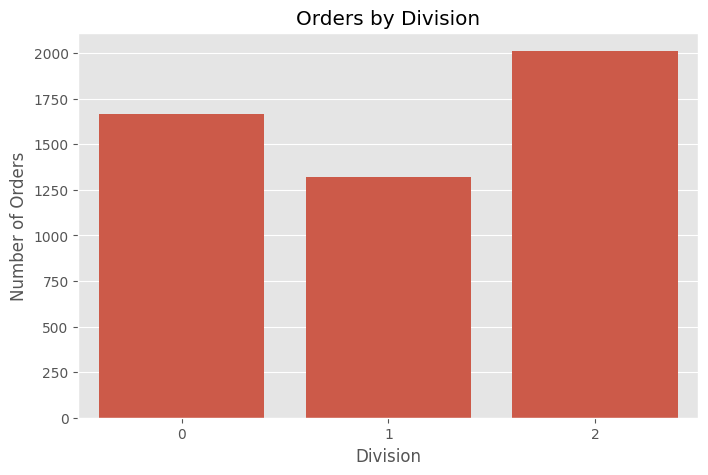

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=orders,
    x='Division'
)

plt.title("Orders by Division")

plt.xlabel("Division")

plt.ylabel("Number of Orders")

plt.show()

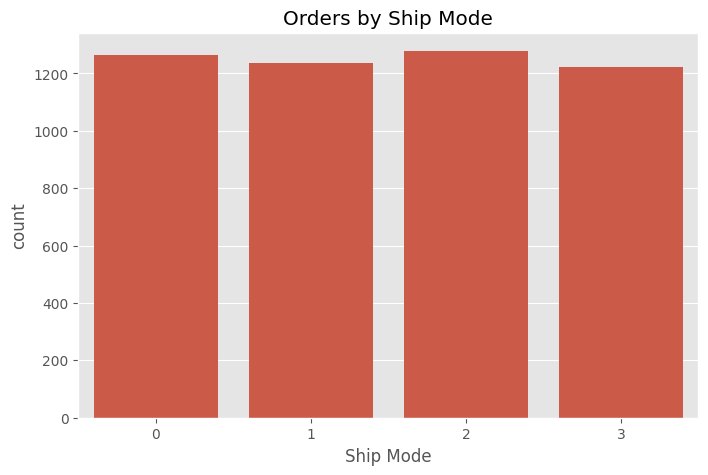

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=orders,
    x='Ship Mode'
)

plt.title("Orders by Ship Mode")

plt.show()

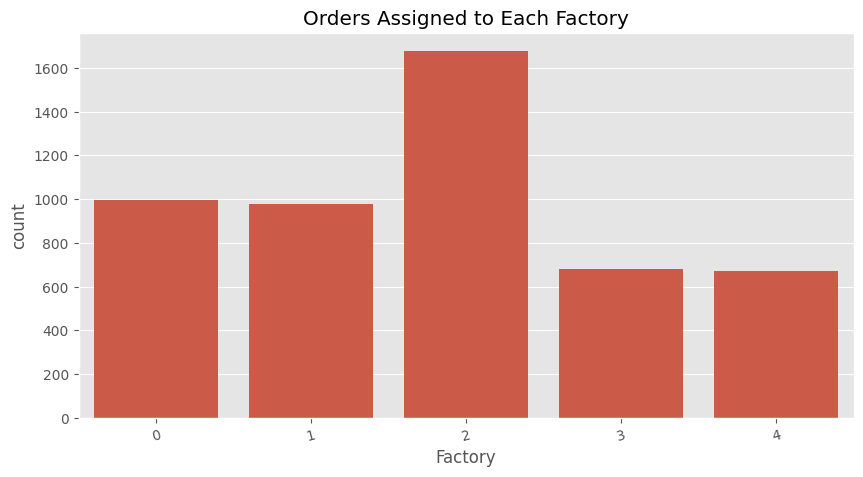

In [36]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=orders,
    x='Factory'
)

plt.xticks(rotation=15)

plt.title("Orders Assigned to Each Factory")

plt.show()

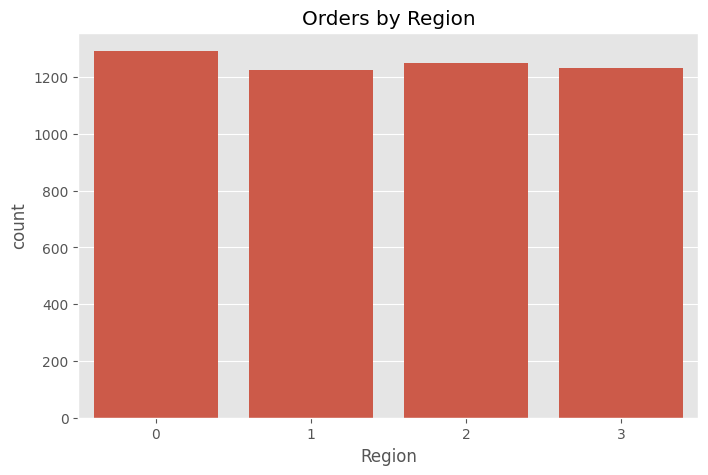

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=orders,
    x='Region'
)

plt.title("Orders by Region")

plt.show()

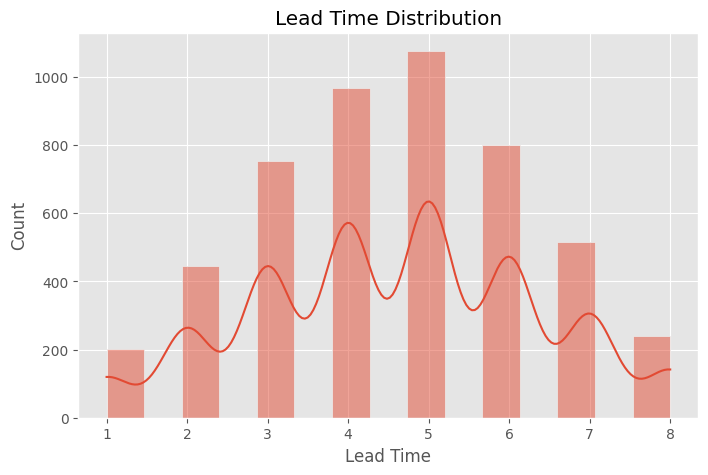

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(
    orders['Lead Time'],
    bins=15,
    kde=True
)

plt.title("Lead Time Distribution")

plt.show()

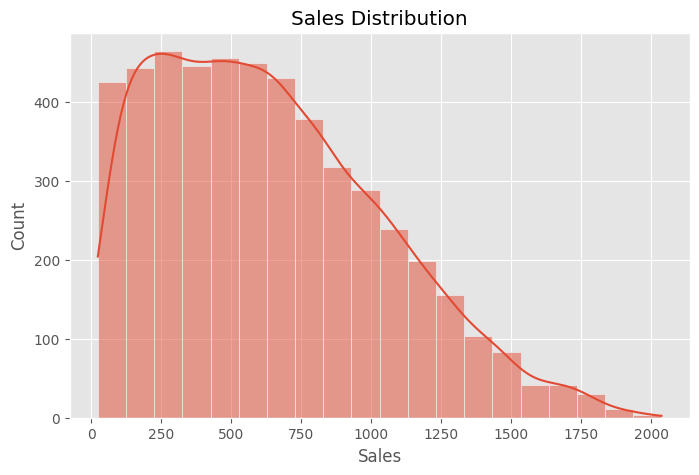

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(
    orders['Sales'],
    bins=20,
    kde=True
)

plt.title("Sales Distribution")

plt.show()

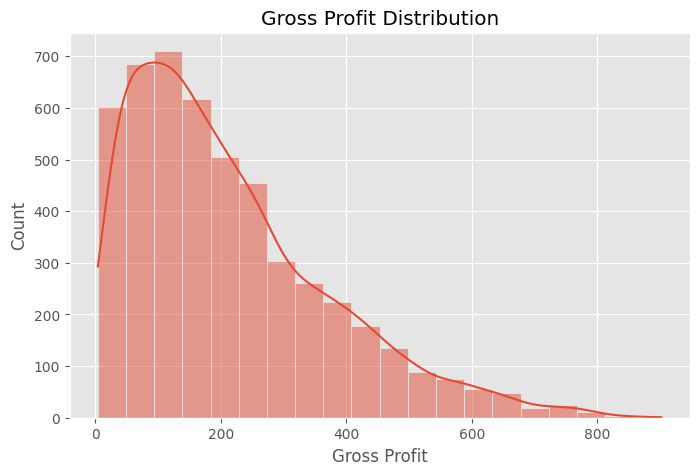

In [40]:
plt.figure(figsize=(8,5))

sns.histplot(
    orders['Gross Profit'],
    bins=20,
    kde=True
)

plt.title("Gross Profit Distribution")

plt.show()

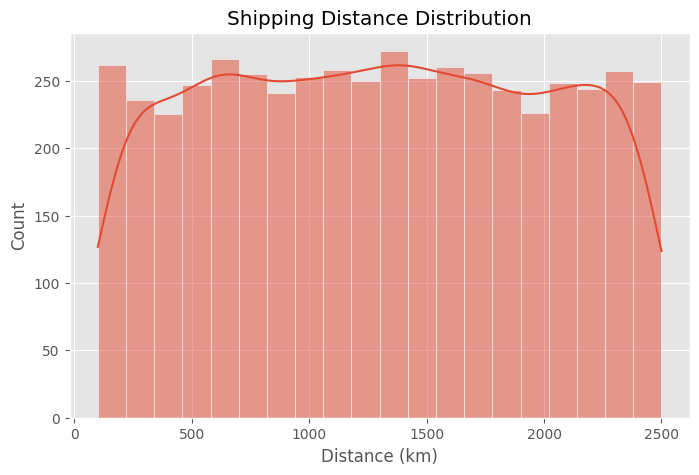

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(
    orders['Distance (km)'],
    bins=20,
    kde=True
)

plt.title("Shipping Distance Distribution")

plt.show()

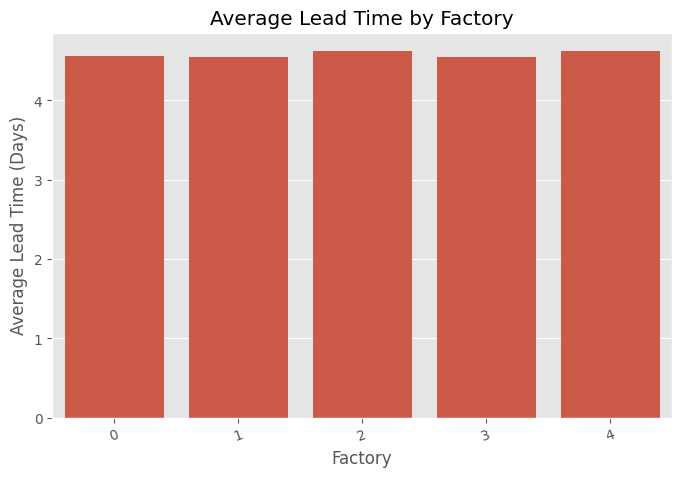

Factory
2    4.624702
4    4.619403
0    4.562249
3    4.553598
1    4.543501
Name: Lead Time, dtype: float64

In [42]:
# ==========================================================
# Average Lead Time by Factory
# ==========================================================

factory_leadtime = (
    orders.groupby('Factory')['Lead Time']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=factory_leadtime.index,
    y=factory_leadtime.values
)

plt.title("Average Lead Time by Factory")
plt.xlabel("Factory")
plt.ylabel("Average Lead Time (Days)")
plt.xticks(rotation=20)

plt.show()

factory_leadtime

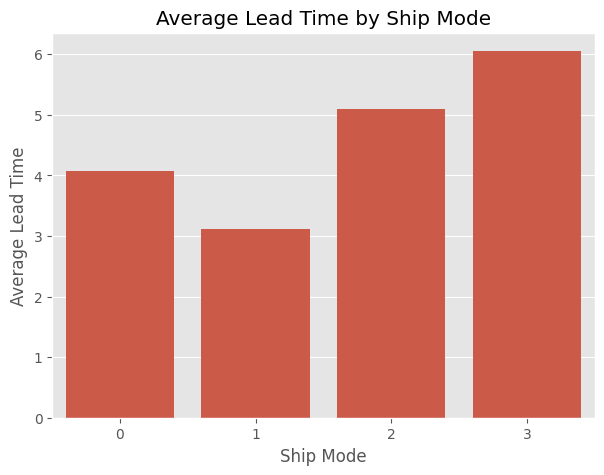

Ship Mode
1    3.121457
0    4.072051
2    5.103286
3    6.053922
Name: Lead Time, dtype: float64

In [43]:
shipmode_leadtime = (
    orders.groupby('Ship Mode')['Lead Time']
    .mean()
    .sort_values()
)

plt.figure(figsize=(7,5))

sns.barplot(
    x=shipmode_leadtime.index,
    y=shipmode_leadtime.values
)

plt.title("Average Lead Time by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Average Lead Time")

plt.show()

shipmode_leadtime

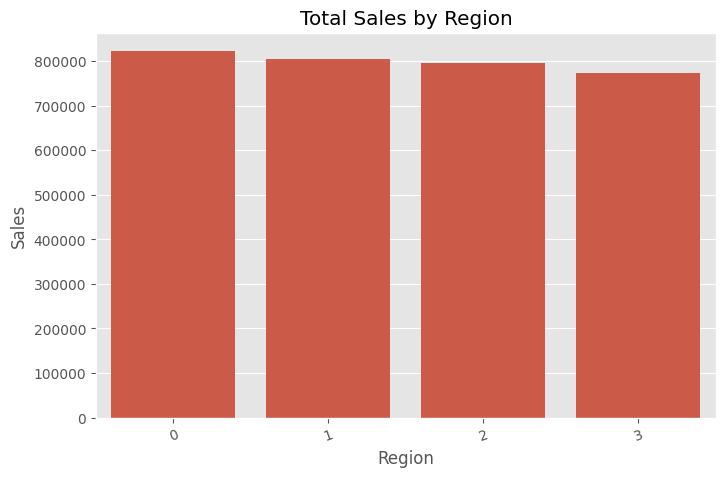

Region
0    822785.35
1    803899.90
2    795992.60
3    773431.90
Name: Sales, dtype: float64

In [44]:
region_sales = (
    orders.groupby('Region')['Sales']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.xticks(rotation=20)

plt.show()

region_sales

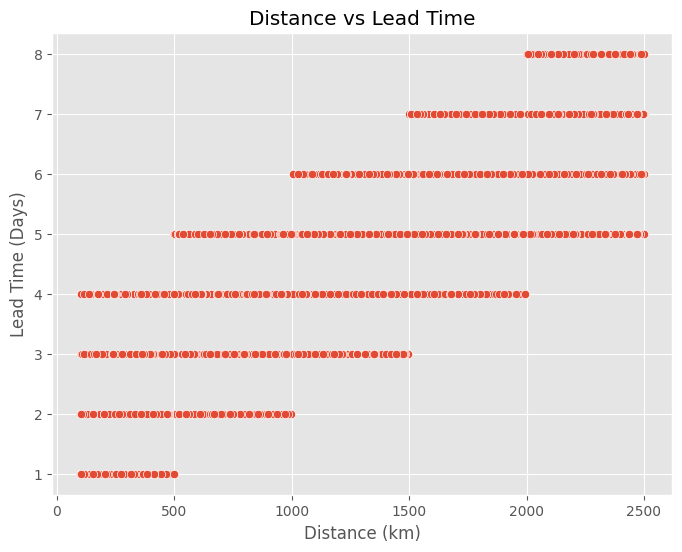

In [45]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=orders,
    x='Distance (km)',
    y='Lead Time'
)

plt.title("Distance vs Lead Time")

plt.xlabel("Distance (km)")

plt.ylabel("Lead Time (Days)")

plt.show()

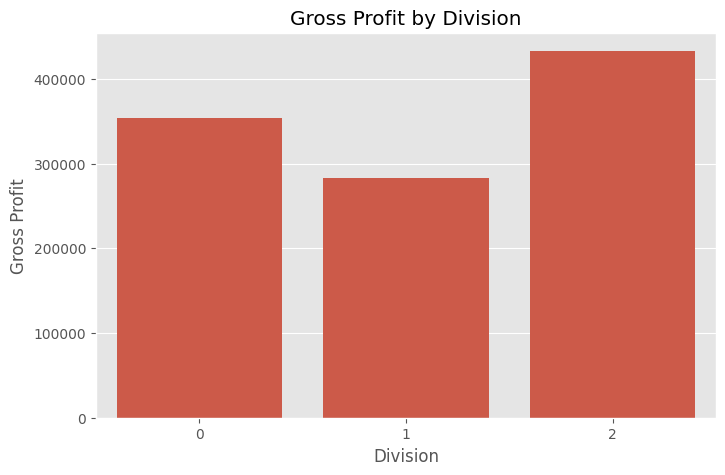

Division
2    433018.22
0    353579.56
1    282728.17
Name: Gross Profit, dtype: float64

In [46]:
division_profit = (
    orders.groupby('Division')['Gross Profit']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=division_profit.index,
    y=division_profit.values
)

plt.title("Gross Profit by Division")

plt.xlabel("Division")

plt.ylabel("Gross Profit")

plt.show()

division_profit

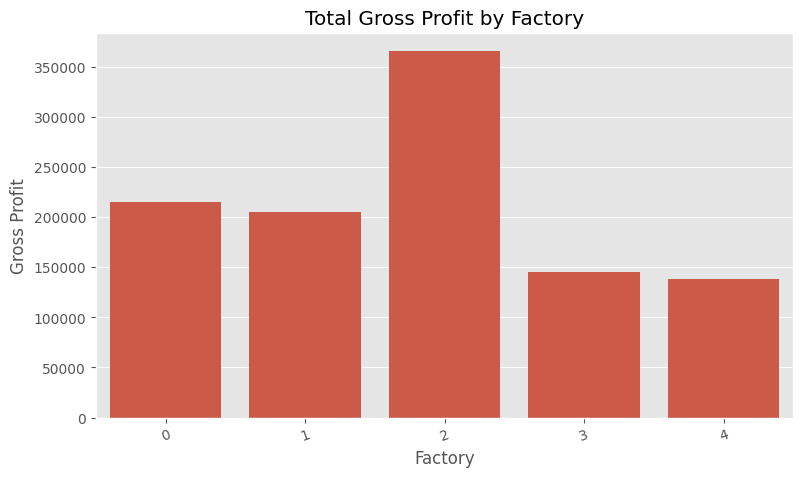

Factory
2    365773.72
0    214982.43
1    205266.06
3    144706.61
4    138597.13
Name: Gross Profit, dtype: float64

In [47]:
# ==========================================================
# Gross Profit by Factory
# ==========================================================

factory_profit = (
    orders.groupby('Factory')['Gross Profit']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))

sns.barplot(
    x=factory_profit.index,
    y=factory_profit.values
)

plt.title("Total Gross Profit by Factory")
plt.xlabel("Factory")
plt.ylabel("Gross Profit")

plt.xticks(rotation=20)

plt.show()

factory_profit

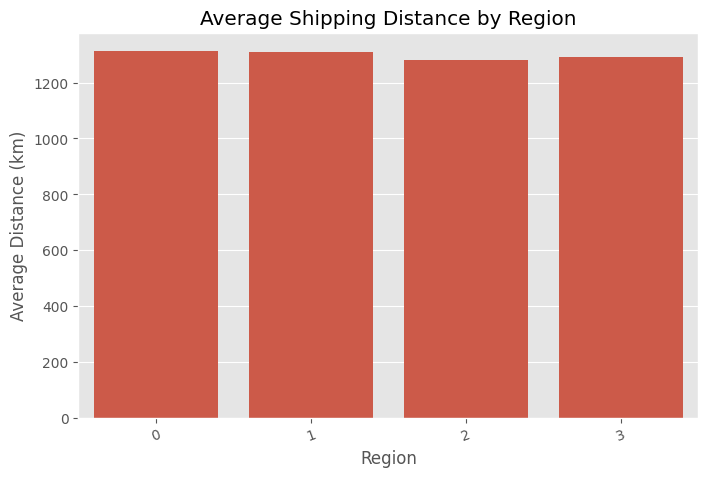

Region
0    1313.480650
1    1310.867156
3    1291.366883
2    1279.761409
Name: Distance (km), dtype: float64

In [48]:
# ==========================================================
# Average Shipping Distance by Region
# ==========================================================

region_distance = (
    orders.groupby('Region')['Distance (km)']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=region_distance.index,
    y=region_distance.values
)

plt.title("Average Shipping Distance by Region")
plt.xlabel("Region")
plt.ylabel("Average Distance (km)")

plt.xticks(rotation=20)

plt.show()

region_distance

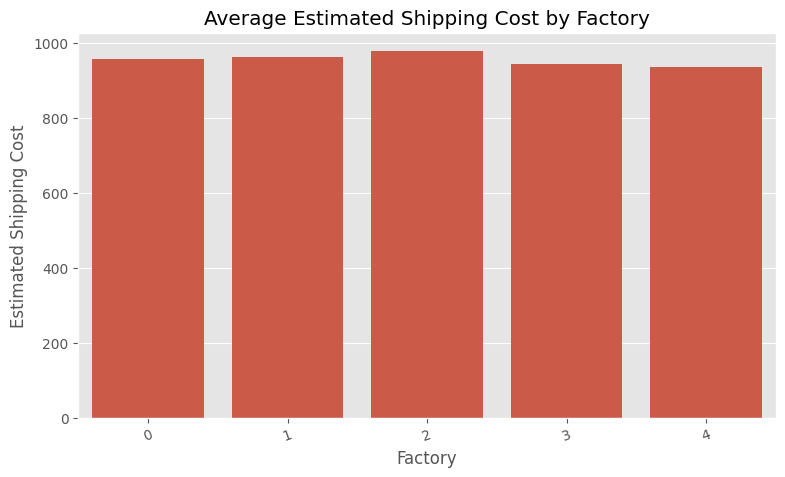

Factory
2    978.442721
1    960.824104
0    956.064508
3    942.480176
4    934.348433
Name: Estimated Shipping Cost, dtype: float64

In [49]:
# ==========================================================
# Average Shipping Cost by Factory
# ==========================================================

factory_shipping = (
    orders.groupby('Factory')['Estimated Shipping Cost']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))

sns.barplot(
    x=factory_shipping.index,
    y=factory_shipping.values
)

plt.title("Average Estimated Shipping Cost by Factory")
plt.xlabel("Factory")
plt.ylabel("Estimated Shipping Cost")

plt.xticks(rotation=20)

plt.show()

factory_shipping

In [50]:
print(orders.columns.tolist())
print(len(orders.columns))

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost', 'Factory', 'Factory Latitude', 'Factory Longitude', 'Distance (km)', 'Lead Time', 'Profit Margin (%)', 'Sales per Unit', 'Cost per Unit', 'Distance Category', 'High Value Order', 'Route ID', 'Shipping Rate ($/km)', 'Estimated Shipping Cost', 'Delivery Efficiency Score', 'Factory Order Count', 'Factory Workload']
34


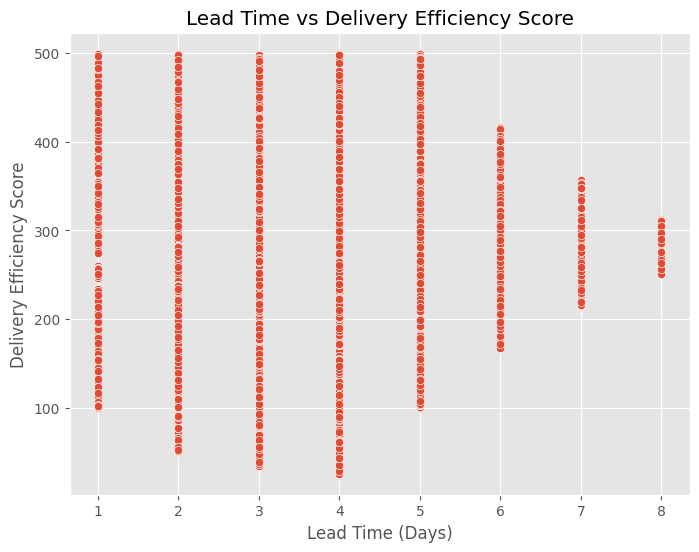

In [51]:
# ==========================================================
# Lead Time vs Delivery Efficiency
# ==========================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=orders,
    x='Lead Time',
    y='Delivery Efficiency Score'
)

plt.title("Lead Time vs Delivery Efficiency Score")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Delivery Efficiency Score")

plt.show()

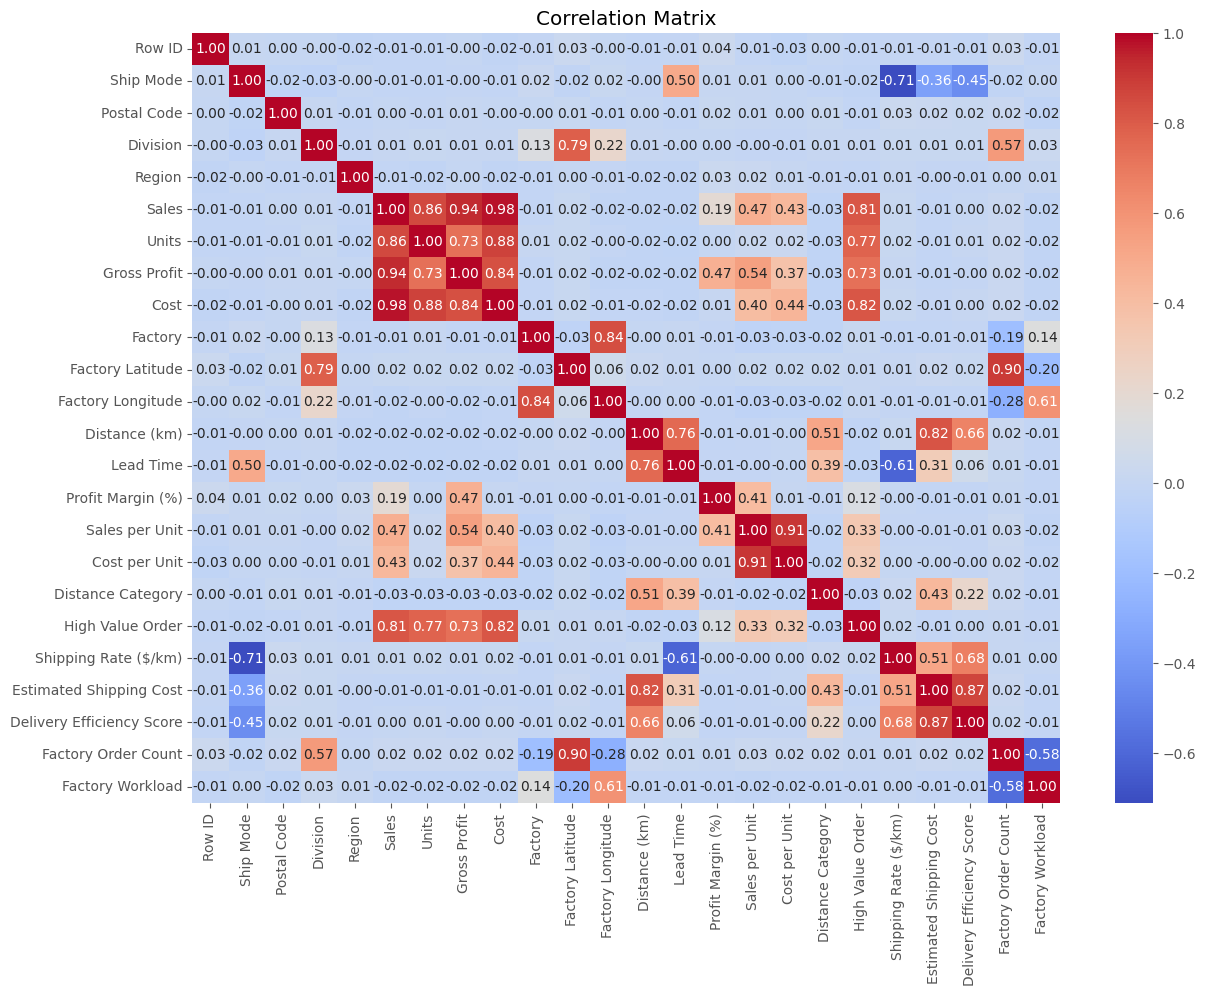

In [52]:
# ==========================================================
# Correlation Heatmap
# ==========================================================

numerical_data = orders.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(14,10))

sns.heatmap(
    numerical_data.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()

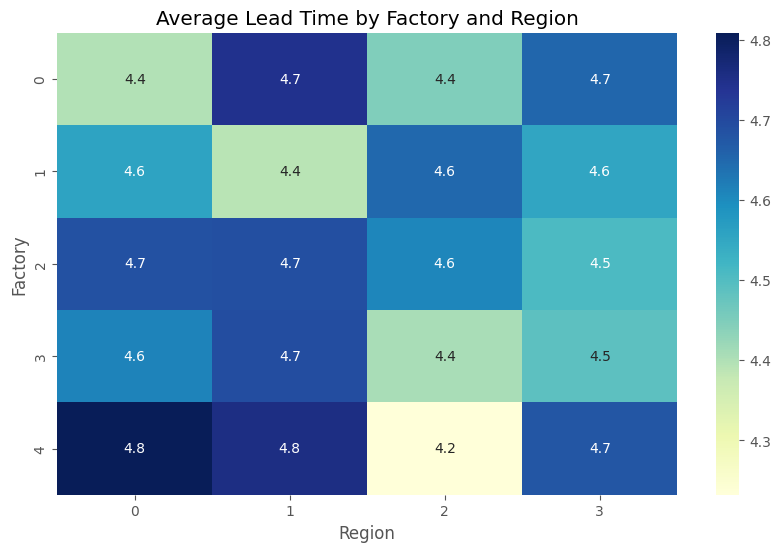

Region,0,1,2,3
Factory,,,,
0,4.396887,4.744939,4.447826,4.652672
1,4.557377,4.391111,4.649254,4.554167
2,4.686047,4.691388,4.608076,4.508600
3,4.611702,4.692308,4.407407,4.487654
4,4.809249,4.755952,4.232143,4.677019


In [55]:
# ==========================================================
# Factory vs Region vs Lead Time
# ==========================================================

pivot_leadtime = orders.pivot_table(
    values='Lead Time',
    index='Factory',
    columns='Region',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot_leadtime,
    annot=True,
    cmap='YlGnBu',
    fmt='.1f'
)

plt.title("Average Lead Time by Factory and Region")

plt.show()

pivot_leadtime

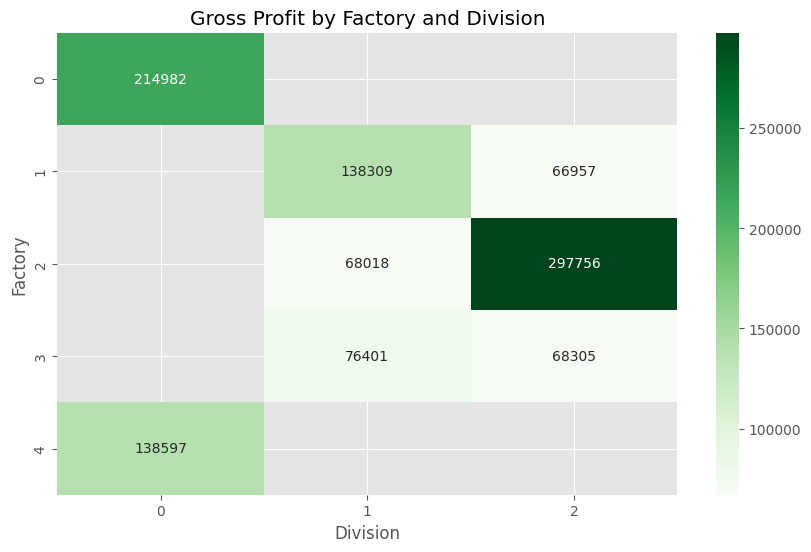

Division,0,1,2
Factory,,,
0,214982.43,NaN,NaN
1,NaN,138309.47,66956.59
2,NaN,68017.57,297756.15
3,NaN,76401.13,68305.48
4,138597.13,NaN,NaN


In [56]:
# ==========================================================
# Factory vs Division vs Gross Profit
# ==========================================================

pivot_profit = orders.pivot_table(
    values='Gross Profit',
    index='Factory',
    columns='Division',
    aggfunc='sum'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot_profit,
    annot=True,
    cmap='Greens',
    fmt='.0f'
)

plt.title("Gross Profit by Factory and Division")

plt.show()

pivot_profit

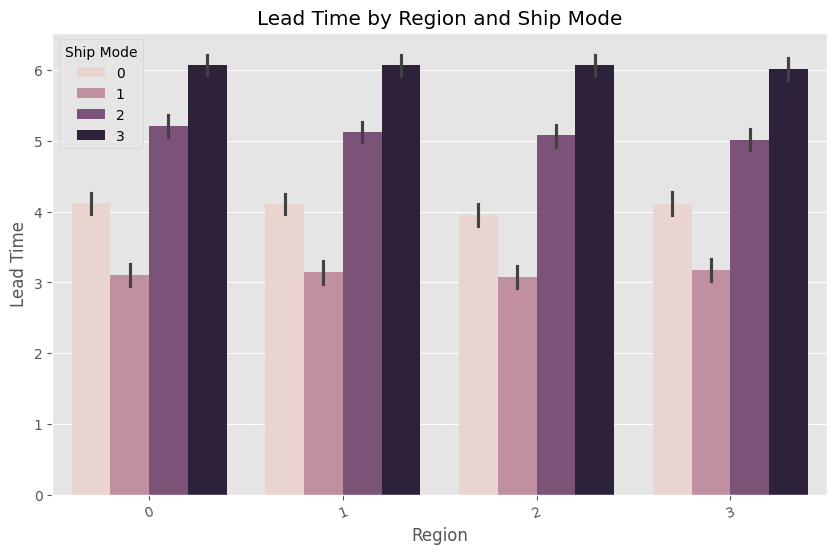

In [57]:
# ==========================================================
# Ship Mode vs Region vs Lead Time
# ==========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=orders,
    x='Region',
    y='Lead Time',
    hue='Ship Mode'
)

plt.title("Lead Time by Region and Ship Mode")

plt.xticks(rotation=20)

plt.show()

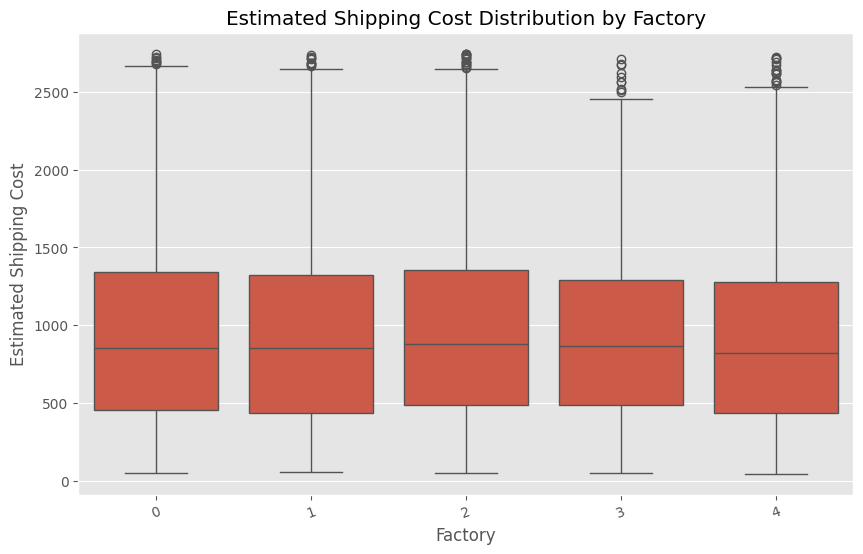

In [58]:
# ==========================================================
# Factory Shipping Cost Distribution
# ==========================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=orders,
    x='Factory',
    y='Estimated Shipping Cost'
)

plt.xticks(rotation=20)

plt.title("Estimated Shipping Cost Distribution by Factory")

plt.show()

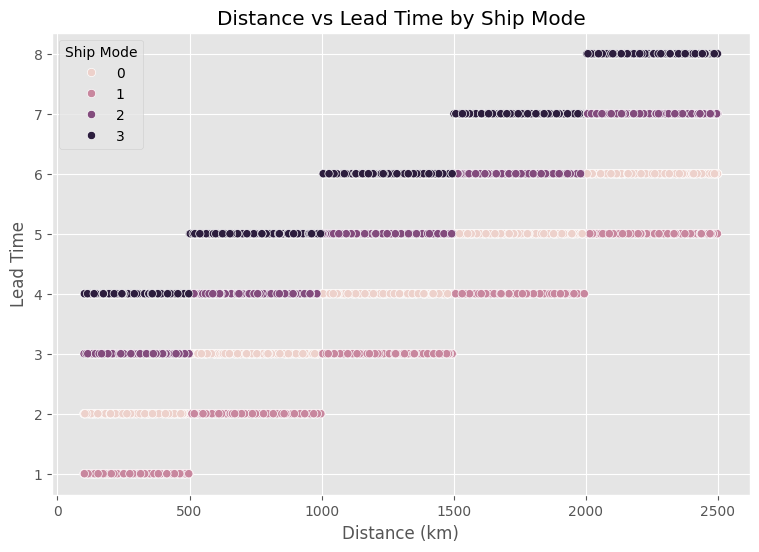

In [59]:
# ==========================================================
# Distance vs Lead Time by Ship Mode
# ==========================================================

plt.figure(figsize=(9,6))

sns.scatterplot(
    data=orders,
    x='Distance (km)',
    y='Lead Time',
    hue='Ship Mode'
)

plt.title("Distance vs Lead Time by Ship Mode")

plt.show()